<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Worksheet7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     UpSampling2D, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

STEP 1: Load, pre - process and add a Noise to the Dataset:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


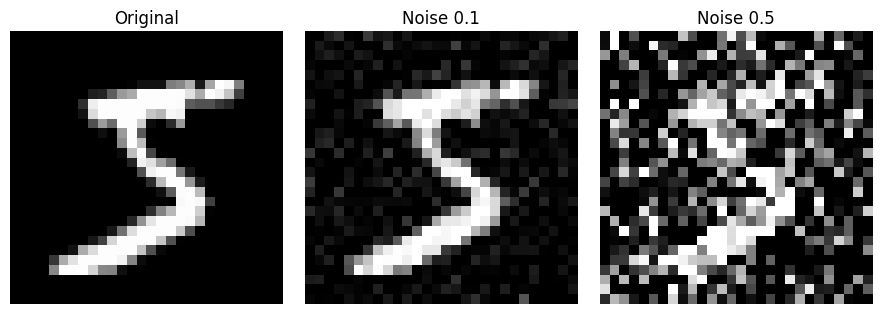

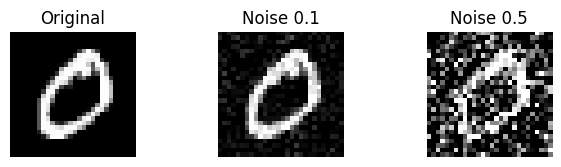

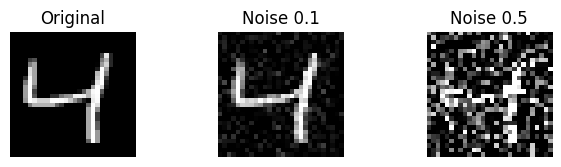

In [ ]:
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
 ax = plt.subplot(n, 3, i * 3 + 1)
 plt.imshow(x_train[i].reshape(28, 28), cmap= 'gray')
 plt.title("Original")
 plt.axis('off')
# Low noise image
 ax = plt.subplot(n, 3, i * 3 + 2)
 plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap= 'gray')
 plt.title("Noise 0.1")
 plt.axis('off')
# High noise image
 ax = plt.subplot(n, 3, i * 3 + 3)
 plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
 plt.title("Noise 0.5")
 plt.axis('off')
 plt.tight_layout()
 plt.show()

STEP 2: Build the Convolutional Denoising Autoencoder Model:

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):

 input_img = Input(shape=input_shape, name="input")
 x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
 x = MaxPooling2D((2, 2), padding='same')(x) #28/2 = 14
 x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
 encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x) # 14/2 = 7
 return input_img, encoded

In [ ]:
def build_decoder(encoded_input):

 x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
 x = UpSampling2D((2, 2))(x) #expand 7*2 = 14
 x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
 x = UpSampling2D((2, 2))(x)# expand  14*2 = 28
 decoded = Conv2D(1, (3, 3), activation='sigmoid' , padding= 'same' , name="decoded")(x)
 return decoded

In [ ]:
#autoencoder structure
def build_autoencoder():

 input_img, encoded_output = build_encoder() #encoder
 decoded_output = build_decoder(encoded_output)#decoder
 autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder") #model creation
 autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
 return autoencoder

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Step 3: Train the Autoencoder:

In [ ]:
autoencoder = build_autoencoder()
history = autoencoder.fit(
 x_train_noisy_high, x_train,
 epochs=10,
 batch_size=128,
 shuffle=True,
 validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1587 - val_loss: 0.1127
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1094 - val_loss: 0.1052
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1042 - val_loss: 0.1018
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1016 - val_loss: 0.1003
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1001 - val_loss: 0.0989
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0989 - val_loss: 0.0976
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0981 - val_loss: 0.0974
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0973 - val_loss: 0.0963
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0967 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0962 - val_loss: 0.0955


Step 4: Evaluate the Autoencoder:

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


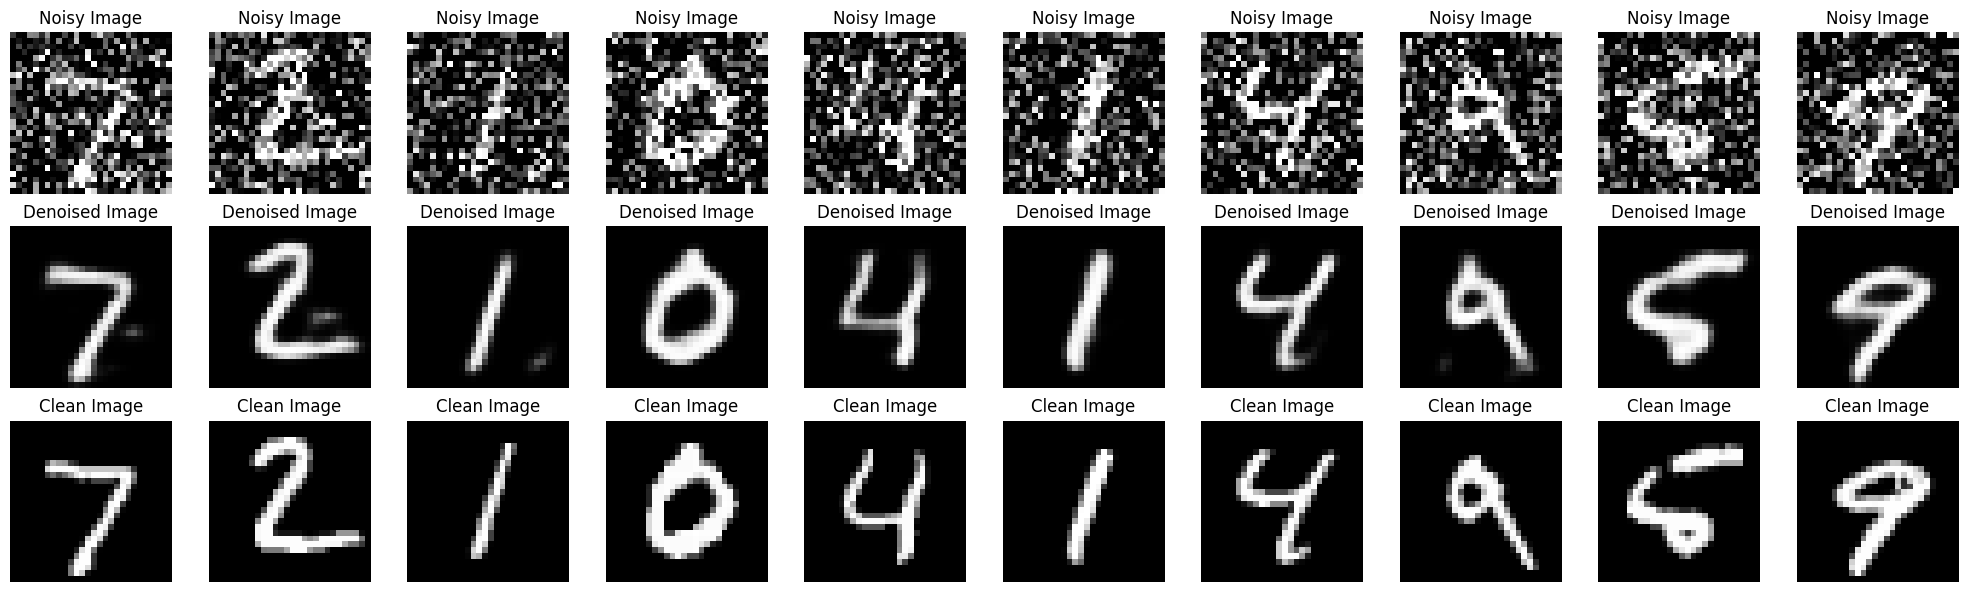

In [ ]:

denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

Exercise: Build a Denoising Convolutional Autoencoder

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam



1. Dataset Preparation and Preprocessing:

In [ ]:
train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"

IMG_SIZE = 28
CHANNELS = 1
NOISE_FACTOR = 0.5
BATCH_SIZE = 128
EPOCHS = 10


In [ ]:

def load_images_from_folder(folder, img_size=28):
    images = []
    labels = []

    class_names = sorted([
        folder_name for folder_name in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, folder_name))
    ])

    class_map = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")   # grayscale
                img = img.resize((img_size, img_size))
                img = np.array(img, dtype=np.float32) / 255.0

                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping corrupted file: {img_path} | Error: {e}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    return images, labels, class_names


In [ ]:
x_train, y_train, class_names = load_images_from_folder(train_dir, IMG_SIZE)
x_test, y_test, _ = load_images_from_folder(test_dir, IMG_SIZE)

print("Class Names:", class_names)
print("Original Train Shape:", x_train.shape)
print("Original Test Shape :", x_test.shape)

Skipping corrupted file: /content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test/digit_1/56143.png | Error: cannot identify image file '/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test/digit_1/56143.png'
Class Names: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Original Train Shape: (17000, 28, 28)
Original Test Shape : (2999, 28, 28)


In [ ]:
x_train = x_train.reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)
x_test = x_test.reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)

print("Reshaped Train Shape:", x_train.shape)
print("Reshaped Test Shape :", x_test.shape)

Reshaped Train Shape: (17000, 28, 28, 1)
Reshaped Test Shape : (2999, 28, 28, 1)


In [ ]:
x_train, y_train = shuffle(x_train, y_train, random_state=42)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nFinal Dataset Split:")
print("Training   :", x_train_final.shape)
print("Validation :", x_val.shape)
print("Testing    :", x_test.shape)



Final Dataset Split:
Training   : (13600, 28, 28, 1)
Validation : (3400, 28, 28, 1)
Testing    : (2999, 28, 28, 1)


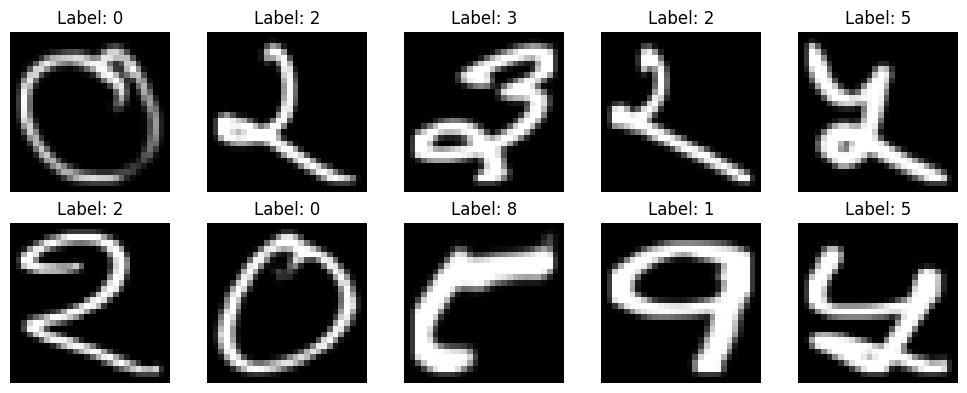

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_final[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Label: {y_train_final[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()



In [ ]:
# Rebuild noisy train/val/test from the correct splits

x_train_noisy = x_train_final + NOISE_FACTOR * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_final.shape
)

x_val_noisy = x_val + NOISE_FACTOR * np.random.normal(
    loc=0.0, scale=1.0, size=x_val.shape
)

x_test_noisy = x_test + NOISE_FACTOR * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

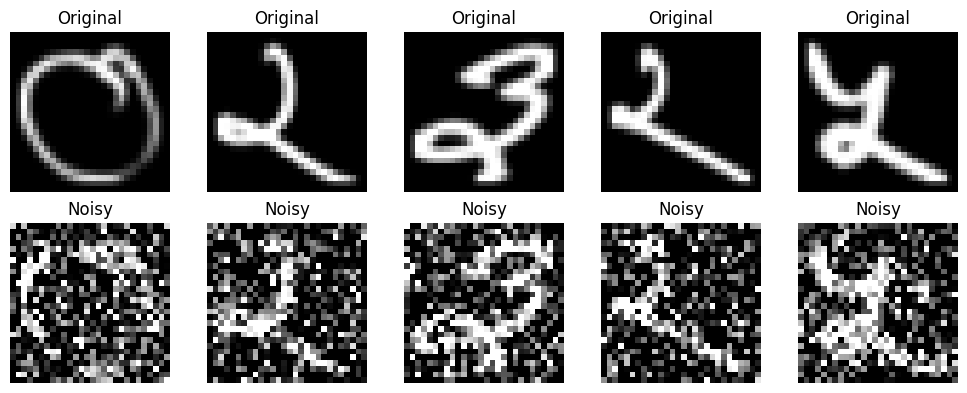

In [ ]:
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train_final[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

def build_autoencoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder


autoencoder = build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("x_train_noisy shape:", x_train_noisy.shape)
print("x_train_final shape:", x_train_final.shape)
print("x_val_noisy shape:", x_val_noisy.shape)
print("x_val shape:", x_val.shape)

x_train_noisy shape: (13600, 28, 28, 1)
x_train_final shape: (13600, 28, 28, 1)
x_val_noisy shape: (3400, 28, 28, 1)
x_val shape: (3400, 28, 28, 1)


In [ ]:
history = autoencoder.fit(
    x_train_noisy,
    x_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.3393 - val_loss: 0.2266
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2145 - val_loss: 0.2062
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2030 - val_loss: 0.2007
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1980 - val_loss: 0.1960
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1949 - val_loss: 0.1936
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1929 - val_loss: 0.1926
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1913 - val_loss: 0.1904
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1903 - val_loss: 0.1896
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1887 - val_loss: 0.1882
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1880 - val_loss: 0.1878


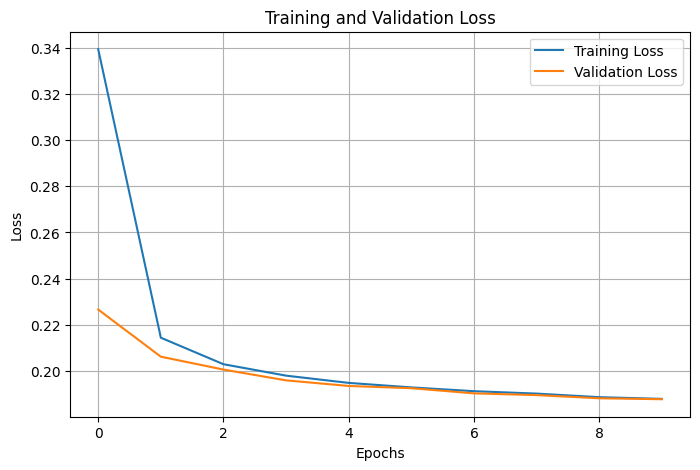

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
denoised_images = autoencoder.predict(x_test_noisy)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


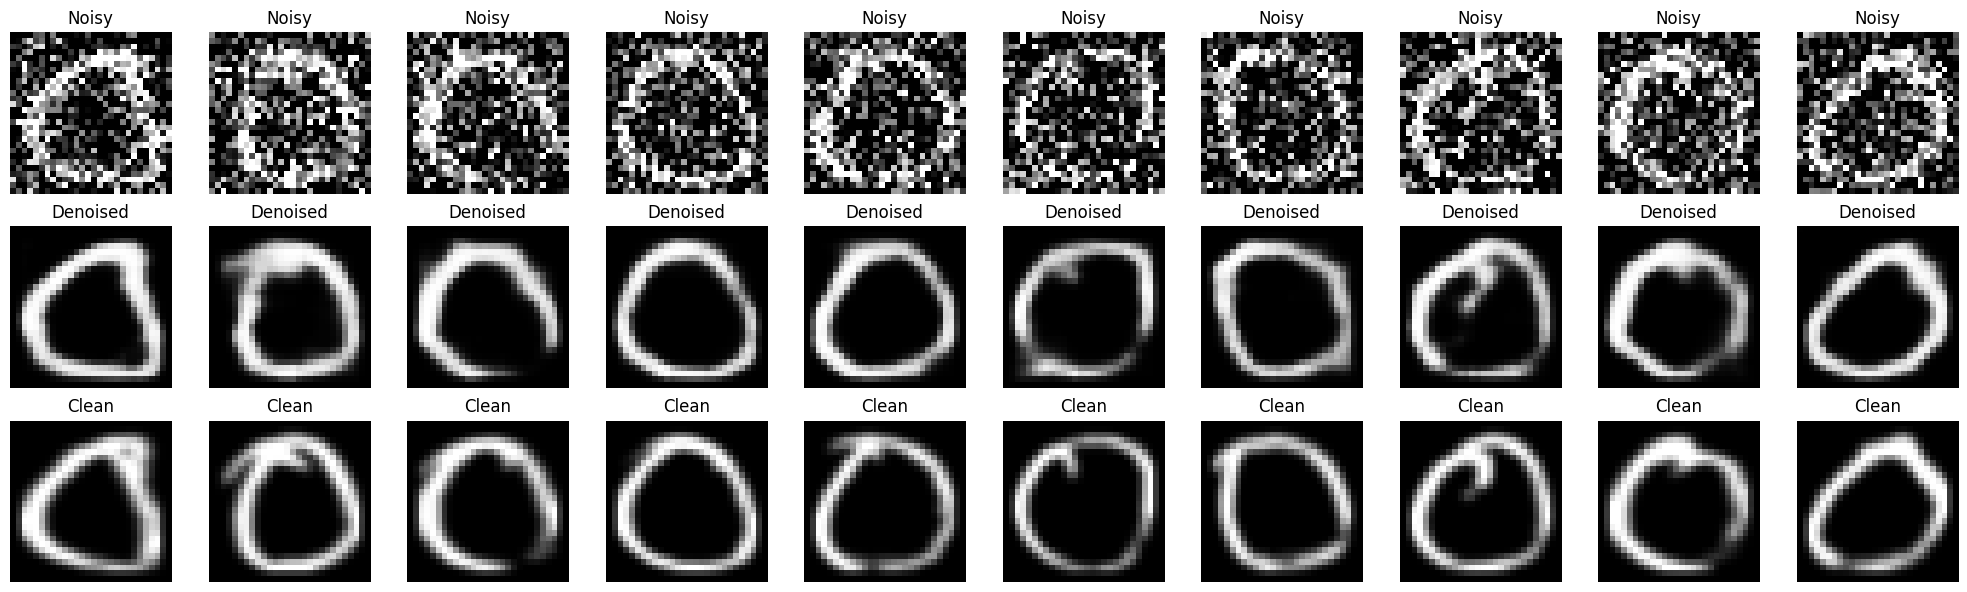

In [ ]:
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        # Denoised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

        # Clean
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_images(x_test_noisy, denoised_images, x_test, n=10)